In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

### Creating random dates.

In [4]:
Date = pd.date_range(start = '2026-03-01',periods = 30, freq='D')
Date

DatetimeIndex(['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04',
               '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16',
               '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20',
               '2026-03-21', '2026-03-22', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-28',
               '2026-03-29', '2026-03-30'],
              dtype='datetime64[us]', freq='D')

### Filling random data with date with a fix number generating code for generating same numbers on all systems.

In [5]:
np.random.seed(40)
Sales = np.random.randint(100,1000,size = 30)
df = pd.DataFrame({'Date':Date,'Sales':Sales})
df.set_index('Date',inplace = True)

In [6]:
df.head()

,Sales
Date,
2026-03-01,426
2026-03-02,319
2026-03-03,107
2026-03-04,265
2026-03-05,540


### Calculating moving average & previous day sales.

In [7]:
df['Moving-Average_7_Days'] = df['Sales'].rolling(window=7).mean()
df['Yesterday_Sales'] = df['Sales'].shift(1)
df.head(10)

,Sales,Moving-Average_7_Days,Yesterday_Sales
Date,,,
2026-03-01,426,NaN,NaN
2026-03-02,319,NaN,426.0
2026-03-03,107,NaN,319.0
2026-03-04,265,NaN,107.0
2026-03-05,540,NaN,265.0
2026-03-06,406,NaN,540.0
2026-03-07,805,409.714286,406.0
2026-03-08,368,401.428571,805.0
2026-03-09,939,490.000000,368.0


### Ploting the moving average pf past 7 days and Sales Trend.

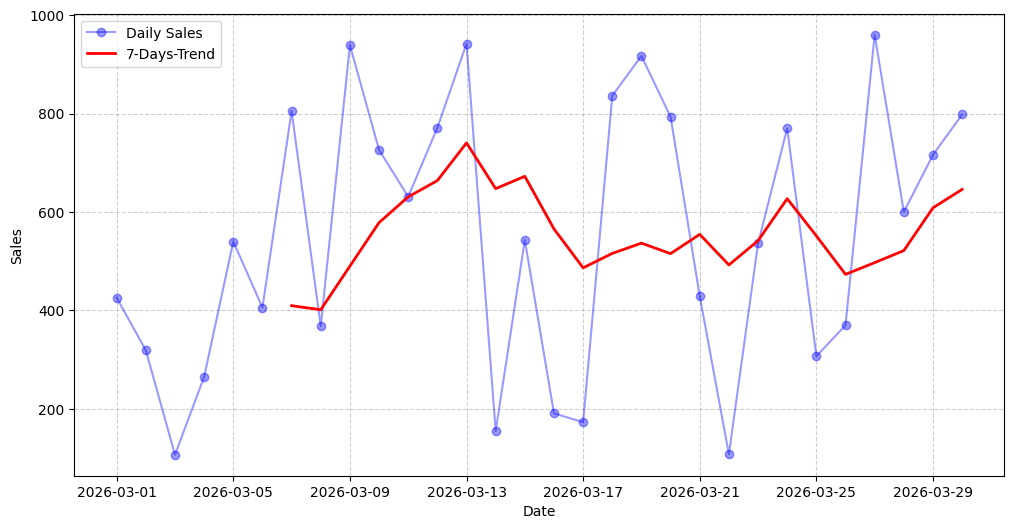

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df['Sales'],label='Daily Sales',color='blue',marker='o',alpha=0.4)
plt.plot(df.index,df['Moving-Average_7_Days'],label = '7-Days-Trend',color='red',linewidth=2)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True,linestyle='--',
alpha=0.6)


### Organising the Sales as per week of a month of weekly analysis & finding the growth percentage.

In [9]:
weekly_data = df['Sales'].resample('W').sum().to_frame()
weekly_data['Growth_Percentage'] = weekly_data['Sales'].pct_change() * 100  # if we have to compare the sales of a  month
# not by its previous sales but by previous year same month the we use periods = 12 for 12 month past comparision pct.change(periods = 12)
weekly_data

,Sales,Growth_Percentage
Date,,
2026-03-01,426,NaN
2026-03-08,2810,559.624413
2026-03-15,4707,67.508897
2026-03-22,3447,-26.768642
2026-03-29,4259,23.556716
2026-04-05,798,-81.263207


### Ploting growth percentage and Sales.

<Axes: xlabel='Date'>

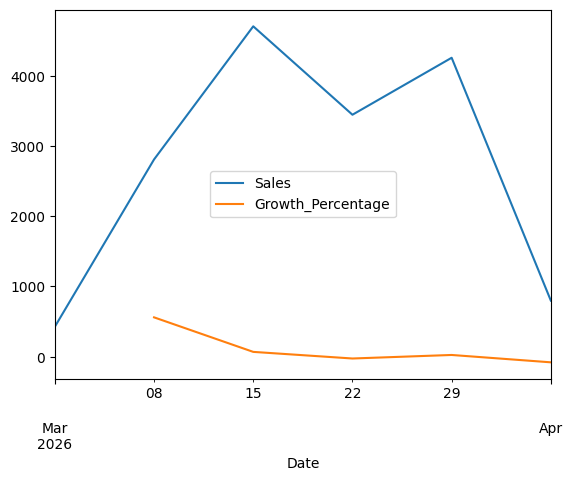

In [10]:
weekly_data.plot()

### Generating diffrent view fr clearly understand the sales trend , seasonality & residuals by decomposing method.

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

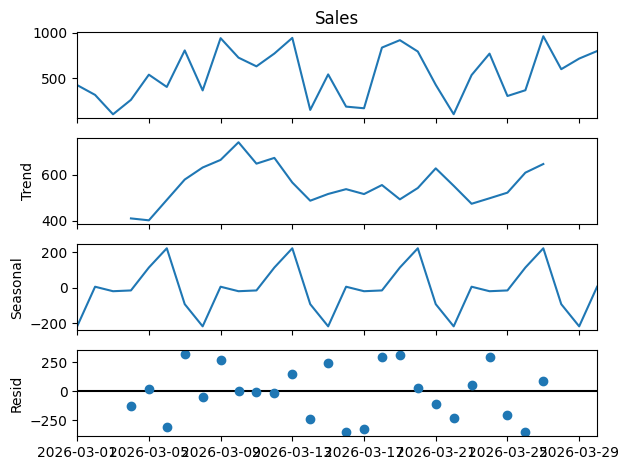

In [12]:
result = seasonal_decompose(df['Sales'], model = 'additive', period = 7)
result.plot()
plt.show()

### Predecting sales based on the last 10 days sales.

Past 10 Days Average: 559
------------------------------
            Prediction-Sales
date                        
2026-03-31               559
2026-04-01               559
2026-04-02               559
2026-04-03               559
2026-04-04               559


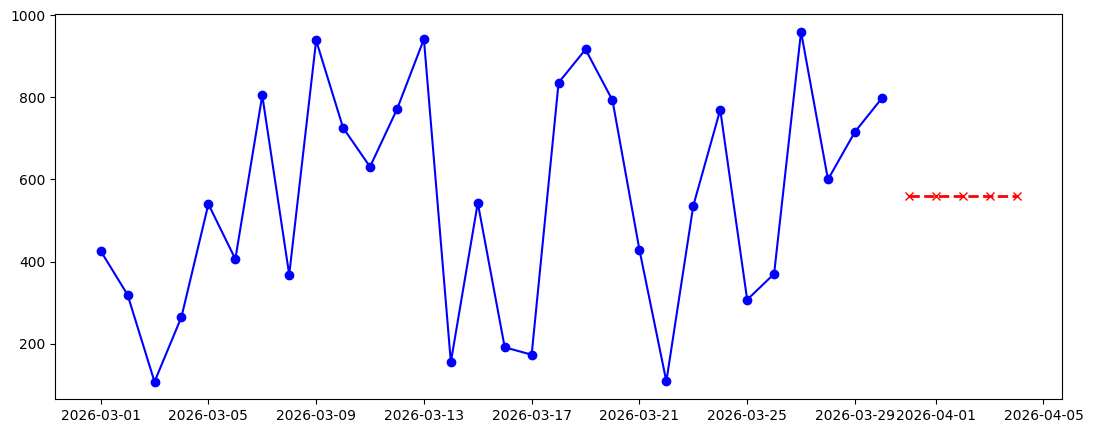

In [13]:
last_7 = df['Sales'].tail(10)
smart_prediction = last_7.mean()
smart_prediction = round(smart_prediction)
print(f"Past 10 Days Average: {smart_prediction}")
print("-" * 30)

future_dates = pd.date_range(start = '2026-03-31',periods=5,freq='D')
future_df = pd.DataFrame({'date':future_dates, 'Prediction-Sales':smart_prediction})
future_df.set_index('date',inplace=True)
print(future_df)
plt.figure(figsize=(13,5))
plt.plot(df.index, df['Sales'], label = 'Sales',color='blue',marker='o')
plt.plot(future_df.index, future_df['Prediction-Sales'],label = 'Future predection', color='red',linestyle = '--',marker='x',linewidth=2)
plt.show()

### Using simple exponential for more accurate predection by analysing past days sales data.

### simple exponential

In [15]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [27]:
smart_model = SimpleExpSmoothing(df['Sales'])
trained_model = smart_model.fit()
print("Data read completed")

Data read completed


C:\Users\uttam\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
smt_prediction = trained_model.forecast(steps=5)
print(smt_prediction)


2026-03-31    586.921456
2026-04-01    586.921456
2026-04-02    586.921456
2026-04-03    586.921456
2026-04-04    586.921456
Freq: D, dtype: float64


### Trend prediction smart exponential

#### Forecasting the future sales based on past days analysis with a dynamic change in sales.

In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [33]:
model = ExponentialSmoothing(df['Sales'],trend='add')

C:\Users\uttam\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [34]:
train_model = model.fit()

In [35]:
answ = train_model.forecast(steps=5)
print(answ)

2026-03-31    665.036587
2026-04-01    672.572292
2026-04-02    680.107997
2026-04-03    687.643702
2026-04-04    695.179407
Freq: D, dtype: float64


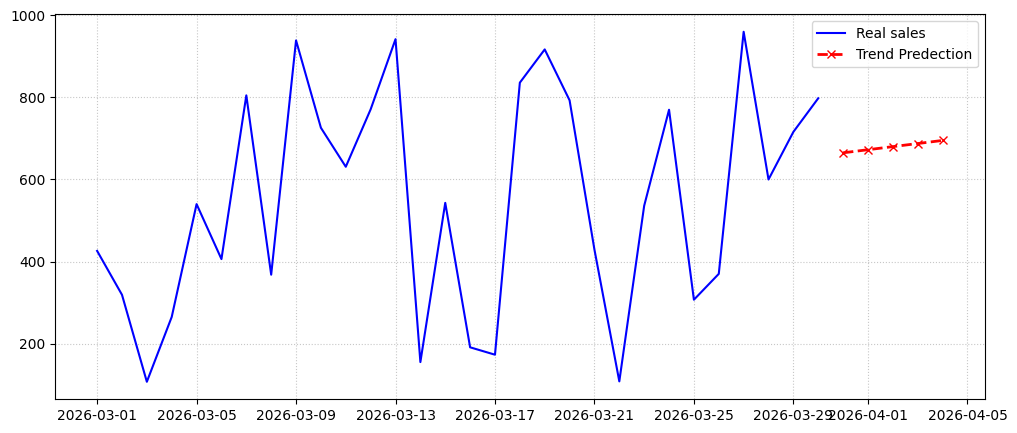

In [38]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Sales'],label='Real sales',color = 'blue')
plt.plot(answ.index, answ,label='Trend Predection',color='red',linestyle='--',marker='x',linewidth=2)
plt.legend()
plt.grid(True, linestyle=":",alpha=0.7)
plt.show()